# DenseNet121 - Final Training & Test Evaluation

## KHOTAA - Smart Diabetic Foot Shield

### Model Selection Summary

Based on the 5-fold stratified cross-validation comparison of 6 deep learning architectures, **DenseNet121** was selected as the best-performing model:

| Rank | Model | CV Accuracy | Std | Macro F1 | AUC-ROC |
|------|-------|------------|-----|----------|--------|
| **1** | **DenseNet121** | **98.42%** | **0.12%** | **0.9935** | **0.9999** |
| 2 | EfficientNetV2S | 97.81% | 0.38% | 0.9890 | 0.9990 |
| 3 | MobileNetV2 | 97.73% | 0.36% | 0.9910 | 0.9998 |
| 4 | ResNet101 | 91.05% | 0.98% | 0.9500 | 0.9964 |
| 5 | GoogLeNet | 88.34% | 1.07% | 0.7189 | 0.9267 |
| 6 | ResNet50 | 88.29% | 0.74% | 0.9158 | 0.9887 |

### Methodology

Now that model selection is complete, we follow the standard post-CV workflow:

1. **Final Training** - Retrain DenseNet121 on **all non-test data** (train + valid = 9,921 samples) to maximize performance
2. **Fixed Epochs** - Train for **30 epochs** (determined by CV: average convergence at 29.8 epochs), no early stopping needed
3. **Test Evaluation** - Evaluate on the **reserved test set** (141 samples, never used during CV or training)

**Why train on all data?** Cross-validation already validated the model and hyperparameters. Holding back a validation set would waste data — the more training data, the better the final model.

## 1. Imports & Configuration

In [1]:
import sys
import os
import json
import time
import numpy as np
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import densenet121, DenseNet121_Weights
from tqdm import tqdm

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Add project paths
sys.path.append('../')
sys.path.append('./')

# Project utilities
from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils.training_engine import create_optimizer
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_curve,
    plot_training_history, print_classification_report,
    show_sample_predictions
)

# ============================================================================
# CONFIGURATION (same hyperparameters validated by 5-fold CV)
# ============================================================================
MODEL_NAME = 'DenseNet121'
BATCH_SIZE = 32
NUM_EPOCHS = 30          # Fixed: CV showed convergence at 29.8 epochs avg
LEARNING_RATE = 0.001    # Same as CV
RESULTS_DIR = 'results/densenet121_final'
DPI = 300

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {device}")
print(f"\nConfiguration (validated by 5-fold CV):")
print(f"  Model: {MODEL_NAME}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS} (fixed, no early stopping)")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Optimizer: SGD (momentum=0.8, weight_decay=1e-4)")
print(f"  Scheduler: StepLR (step_size=10, gamma=0.1)")

PyTorch version: 2.10.0+cpu
CUDA available: False
Device: cpu

Configuration (validated by 5-fold CV):
  Model: DenseNet121
  Batch Size: 32
  Epochs: 30 (fixed, no early stopping)
  Learning Rate: 0.001
  Optimizer: SGD (momentum=0.8, weight_decay=1e-4)
  Scheduler: StepLR (step_size=10, gamma=0.1)


## 2. Load Dataset & Statistics

In [2]:
# Load dataset
loader = SplitFolderDatasetLoader(root_dir='../../dataset')
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"\nClasses: {classes}")
print(f"Number of classes: {num_classes}")

# Initialize preprocessing (same as CV)
preprocessor = DFUPreprocessing()
train_transform = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# Dataset class
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Load all splits
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val = loader.load_split_paths('valid')
X_test, y_test = loader.load_split_paths('test')

# FINAL TRAINING: combine train + valid for maximum training data
# CV already validated the model — no need to hold back a validation set
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# Create datasets
train_dataset = DFUDataset(X_all, y_all, transform=train_transform)
test_dataset = DFUDataset(X_test, y_test, transform=val_test_transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n{'='*60}")
print(f"DATASET SUMMARY")
print(f"{'='*60}")
print(f"Training samples:   {len(X_all):,} (train + valid combined)")
print(f"  - from train/:    {len(X_train):,}")
print(f"  - from valid/:    {len(X_val):,}")
print(f"Test samples:       {len(X_test):,} (reserved, never seen)")
print(f"Total:              {len(X_all) + len(X_test):,}")
print(f"{'='*60}")

[DatasetLoader] Root: c:\Users\sara2\Documents\KHOTAA\dataset
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']

Classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Number of classes: 4
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 9639 images
[DatasetLoader] Split 'valid': 282 images
[DatasetLoader] Split 'test': 141 images

DATASET SUMMARY
Training samples:   9,921 (train + valid combined)
  - from train/:    9,639
  - from valid/:    282
Test samples:       141 (reserved, never seen)
Total:              10,062


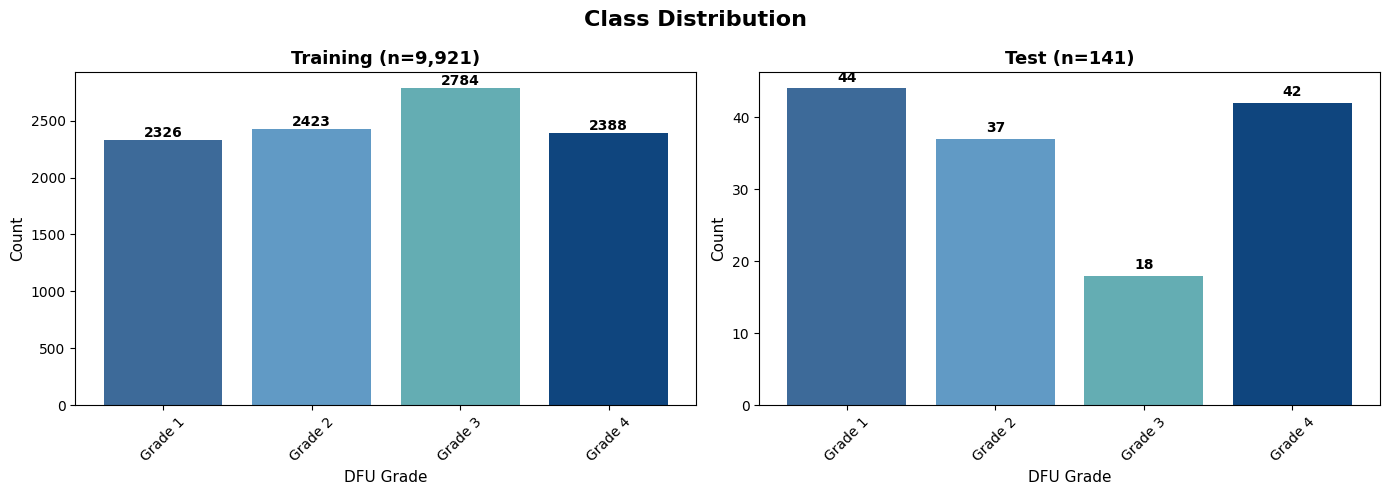

In [3]:
# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution', fontsize=16, fontweight='bold')

colors = ['#3d6a99', '#619ac5', '#64adb3', '#0f457e']

# Training (combined)
ax = axes[0]
unique, counts = np.unique(y_all, return_counts=True)
bars = ax.bar([classes[u] for u in unique], counts, color=colors)
ax.set_title(f'Training (n={len(y_all):,})', fontsize=13, fontweight='bold')
ax.set_xlabel('DFU Grade', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Test
ax = axes[1]
unique, counts = np.unique(y_test, return_counts=True)
bars = ax.bar([classes[u] for u in unique], counts, color=colors)
ax.set_title(f'Test (n={len(y_test)})', fontsize=13, fontweight='bold')
ax.set_xlabel('DFU Grade', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Model Definition

In [4]:
def create_densenet_model(num_classes=4, pretrained=True):
    """
    Create DenseNet121 model for DFU classification.
    Same architecture used during cross-validation.
    """
    if pretrained:
        model = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    else:
        model = models.densenet121(weights=None)
    
    # Replace final classifier: Linear(1024 -> num_classes)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    
    return model

# Create model
model = create_densenet_model(num_classes=num_classes, pretrained=True)
model = model.to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"{'='*60}")
print(f"MODEL SUMMARY")
print(f"{'='*60}")
print(f"Architecture: DenseNet121")
print(f"Pretrained: ImageNet (IMAGENET1K_V1)")
print(f"Input size: 3 x 224 x 224")
print(f"Output classes: {num_classes}")
print(f"Final classifier: {model.classifier}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {device}")
print(f"{'='*60}")

MODEL SUMMARY
Architecture: DenseNet121
Pretrained: ImageNet (IMAGENET1K_V1)
Input size: 3 x 224 x 224
Output classes: 4
Final classifier: Linear(in_features=1024, out_features=4, bias=True)
Total parameters: 6,957,956
Trainable parameters: 6,957,956
Device: cpu


## 4. Training Configuration

In [5]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: SGD with momentum=0.8 (same as CV)
optimizer = create_optimizer(model, optimizer_type='sgd', lr=LEARNING_RATE, momentum=0.8)

# Learning rate scheduler: StepLR (same as CV)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print(f"\n{'='*60}")
print(f"TRAINING CONFIGURATION")
print(f"{'='*60}")
print(f"Loss Function: CrossEntropyLoss")
print(f"Optimizer: SGD (lr={LEARNING_RATE}, momentum=0.8, weight_decay=1e-4)")
print(f"Scheduler: StepLR (step_size=10, gamma=0.1)")
print(f"Epochs: {NUM_EPOCHS} (fixed, determined by CV avg convergence)")
print(f"Early Stopping: DISABLED (not needed, CV validated training duration)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Training Data: {len(train_dataset):,} samples (all non-test data)")
print(f"{'='*60}")

Created SGD optimizer: lr=0.001, momentum=0.8, weight_decay=0.0001

TRAINING CONFIGURATION
Loss Function: CrossEntropyLoss
Optimizer: SGD (lr=0.001, momentum=0.8, weight_decay=1e-4)
Scheduler: StepLR (step_size=10, gamma=0.1)
Epochs: 30 (fixed, determined by CV avg convergence)
Early Stopping: DISABLED (not needed, CV validated training duration)
Batch Size: 32
Training Data: 9,921 samples (all non-test data)


## 5. Final Training

Training on all 9,921 samples for 30 fixed epochs. No validation set is used — the optimal training duration (30 epochs) was determined by cross-validation.

In [ ]:
print(f"{'='*60}")
print(f"STARTING FINAL TRAINING")
print(f"{'='*60}")
print(f"Training on {len(train_dataset):,} samples (train + valid combined)")
print(f"Epochs: {NUM_EPOCHS} (fixed, no early stopping)")
print(f"Test set ({len(test_dataset)} samples) reserved for evaluation")
print(f"{'='*60}\n")

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
}

# === Checkpoint setup ===
checkpoint_dir = 'checkpoints/densenet121_final'
os.makedirs(checkpoint_dir, exist_ok=True)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # === Train ===
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    
    # Step scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}% | LR: {current_lr:.6f}")

    # === Save checkpoint ===
    checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
    torch.save({
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': epoch_loss,
        'train_acc': epoch_acc,
        'lr': current_lr
    }, checkpoint_path)
    print(f"SUCCESS: Checkpoint saved: {checkpoint_path}")

training_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Final training accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"Final training loss: {history['train_loss'][-1]:.4f}")
print(f"{'='*60}")

STARTING FINAL TRAINING
Training on 9,921 samples (train + valid combined)
Epochs: 30 (fixed, no early stopping)
Test set (141 samples) reserved for evaluation



Epoch 1/30: 100%|██████████| 311/311 [31:00<00:00,  5.98s/it, loss=1.6339, acc=56.74%]


Epoch 1/30 | Loss: 1.0068 | Acc: 56.74% | LR: 0.001000
SUCCESS: Checkpoint saved: checkpoints\densenet121_final\fold_1\checkpoint_epoch_1.pth


Epoch 2/30:  42%|████▏     | 132/311 [18:47<18:45,  6.29s/it, loss=0.8100, acc=68.54%]  

## 6. Save Final Model

In [ ]:
# Create results directory
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save the final model (last epoch, trained on all data)
final_model_path = os.path.join(RESULTS_DIR, 'densenet121_final_model.pt')
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved: {final_model_path}")
print(f"Model size: {os.path.getsize(final_model_path) / (1024*1024):.2f} MB")

Final model saved: results/densenet121_final\densenet121_final_model.pt
Model size: 27.12 MB


## 7. Training Curves

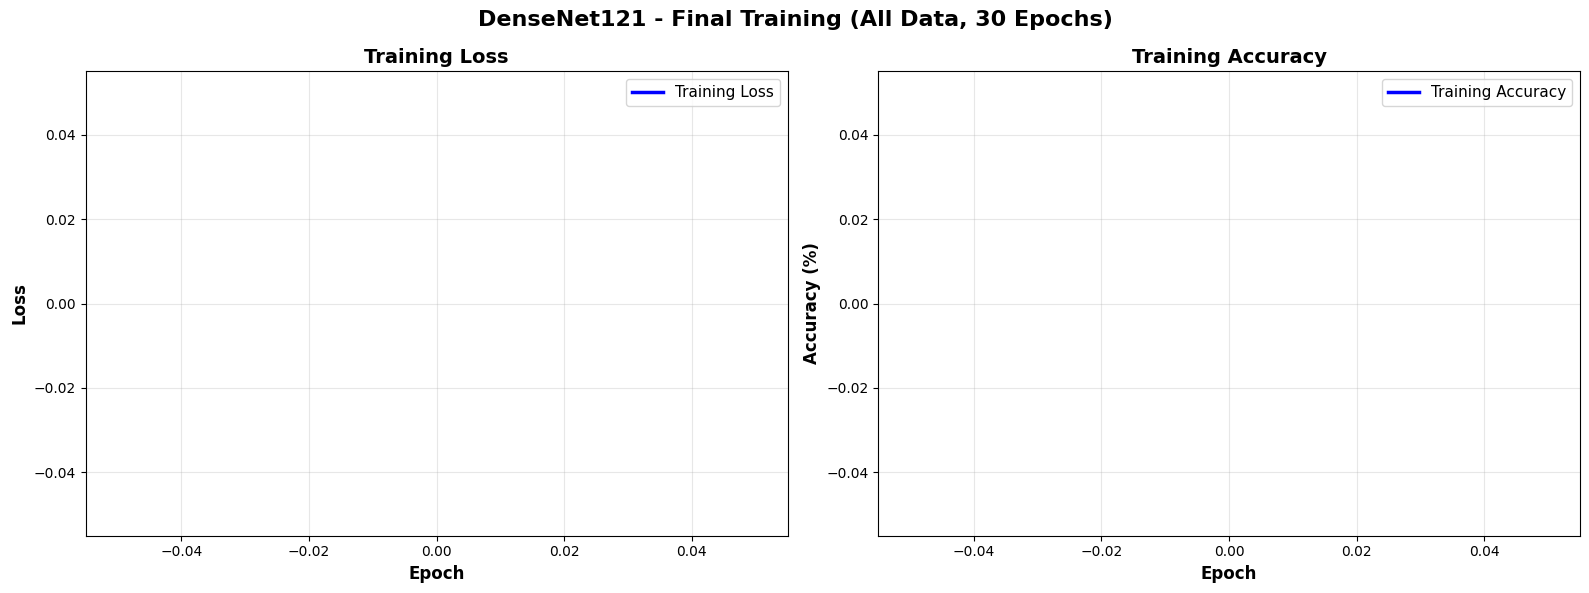

C:\Users\sara2\AppData\Local\Temp\ipykernel_20244\765203004.py:35: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  temp_scheduler.step()


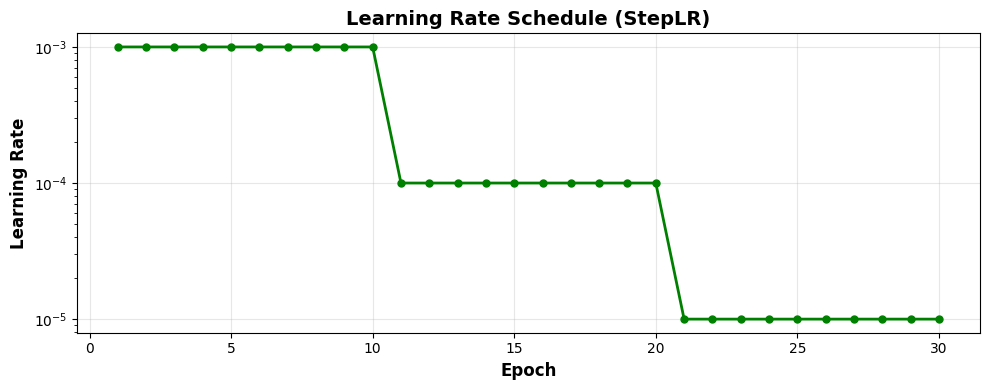

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{MODEL_NAME} - Final Training (All Data, {NUM_EPOCHS} Epochs)', fontsize=16, fontweight='bold')

epochs = range(1, len(history['train_loss']) + 1)

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'b-', lw=2.5, label='Training Loss')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
train_acc_pct = [acc * 100 for acc in history['train_acc']]
ax.plot(epochs, train_acc_pct, 'b-', lw=2.5, label='Training Accuracy')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'densenet121_final_training_curves.png'), dpi=DPI, bbox_inches='tight')
plt.show()

# LR schedule visualization
lr_values = []
temp_optimizer = torch.optim.SGD([torch.nn.Parameter(torch.zeros(1))], lr=LEARNING_RATE)
temp_scheduler = optim.lr_scheduler.StepLR(temp_optimizer, step_size=10, gamma=0.1)
for e in range(NUM_EPOCHS):
    lr_values.append(temp_optimizer.param_groups[0]['lr'])
    temp_scheduler.step()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, NUM_EPOCHS+1), lr_values, 'g-o', lw=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_title('Learning Rate Schedule (StepLR)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Test Set Evaluation

Evaluating the final model on the **reserved test set (141 samples)** — these images were never seen during cross-validation or final training.

In [ ]:
print(f"{'='*60}")
print(f"TEST SET EVALUATION")
print(f"{'='*60}")
print(f"Evaluating on {len(test_dataset)} test samples")
print(f"These samples were NEVER used during CV or training")
print(f"{'='*60}\n")

# Set model to evaluation mode
model.eval()

# Run inference on test set
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

test_predictions = np.concatenate(all_preds)
test_true_labels = np.concatenate(all_labels)
test_pred_proba = np.vstack(all_probs)

# Calculate comprehensive metrics
test_metrics = calculate_metrics(
    y_true=test_true_labels,
    y_pred=test_predictions,
    y_pred_proba=test_pred_proba,
    class_names=classes,
    average='macro'
)

# Print comprehensive metrics
print_metrics(test_metrics, title=f"{MODEL_NAME} - Test Set Results")

# Print classification report
print_classification_report(test_true_labels, test_predictions, classes)

# Summary
correct = np.sum(test_predictions == test_true_labels)
incorrect = np.sum(test_predictions != test_true_labels)

print(f"\n{'='*60}")
print(f"TEST RESULTS SUMMARY")
print(f"{'='*60}")
print(f"Total test samples: {len(test_true_labels)}")
print(f"Correct predictions: {correct}")
print(f"Incorrect predictions: {incorrect}")
print(f"Test Accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"Macro Precision: {test_metrics['precision']*100:.2f}%")
print(f"Macro Recall: {test_metrics['recall']*100:.2f}%")
print(f"Macro Specificity: {test_metrics['specificity']*100:.2f}%")
print(f"Macro F1-Score: {test_metrics['f1_score']*100:.2f}%")
print(f"MCC: {test_metrics['mcc']:.4f}")
if test_metrics.get('auc') is not None:
    print(f"Macro AUC-ROC: {test_metrics['auc']:.4f}")
print(f"{'='*60}")

TEST SET EVALUATION
Evaluating on 141 test samples
These samples were NEVER used during CV or training


                    DenseNet121 - Test Set Results                    

Overall Performance Metrics:
   Accuracy:    66.67%
   Precision:   67.28% (PPV - Positive Predictive Value)
   Recall:      64.59% (Sensitivity/TPR)
   Sensitivity: 64.59% (True Positive Rate)
   Specificity: 88.51% (True Negative Rate)
   F1-Score:    64.72% (F-Measure)
   MCC:         0.5477 (Matthews Correlation Coefficient)
   AUC-ROC:     0.8459 (Area Under Curve)

Metric Formulas:
   Precision (PPV) = TP / (TP + FP)
   Recall (Sensitivity) = TP / (TP + FN)
   Specificity = TN / (TN + FP)
   F1-Score = 2PR / (P + R)
   MCC = (TP×TN - FP×FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN))

Per-Class Detailed Metrics:

   Grade 1:
      Precision (PPV):  70.97%
      Recall:           50.00%
      Sensitivity (TPR): 50.00%
      Specificity (TNR): 90.72%
      F1-Score:         58.67%

   Grade 2:
      Precision (PPV):  

## 9. Test Set Visualizations

In [ ]:
# 9.1 Confusion Matrix (Raw Counts)
plot_confusion_matrix(
    y_true=test_true_labels,
    y_pred=test_predictions,
    class_names=classes,
    figsize=(10, 8),
    normalize=False,
    save_path=os.path.join(RESULTS_DIR, 'densenet121_final_confusion_matrix.png')
)

In [ ]:
# 9.2 Confusion Matrix (Normalized)
plot_confusion_matrix(
    y_true=test_true_labels,
    y_pred=test_predictions,
    class_names=classes,
    figsize=(10, 8),
    normalize=True,
    save_path=os.path.join(RESULTS_DIR, 'densenet121_final_confusion_matrix_normalized.png')
)

In [ ]:
# 9.3 ROC Curve with Per-Class AUC
plot_roc_curve(
    y_true=test_true_labels,
    y_pred_proba=test_pred_proba,
    class_names=classes,
    save_path=os.path.join(RESULTS_DIR, 'densenet121_final_roc_curve.png')
)

In [ ]:
# 9.4 Per-Class Metrics Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'{MODEL_NAME} - Per-Class Test Metrics', fontsize=16, fontweight='bold')

metric_names = ['precision', 'recall', 'f1']
metric_titles = ['Precision', 'Recall (Sensitivity)', 'F1-Score']
colors = ['#3d6a99', '#619ac5', '#64adb3', '#0f457e']

for ax, metric_key, metric_title in zip(axes, metric_names, metric_titles):
    values = [test_metrics.get(f'{metric_key}_{cls}', 0) * 100 for cls in classes]
    bars = ax.bar(classes, values, color=colors)
    ax.set_title(metric_title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_ylim([0, 105])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'densenet121_final_per_class_metrics.png'), dpi=DPI, bbox_inches='tight')
plt.show()

In [ ]:
# 9.5 Sample Predictions
sample_images = []
sample_true = []
sample_pred = []
n_samples = 9

for i in range(min(n_samples, len(X_test))):
    img = Image.open(X_test[i]).convert('RGB')
    img = img.resize((224, 224))
    sample_images.append(np.array(img))
    sample_true.append(test_true_labels[i])
    sample_pred.append(test_predictions[i])

show_sample_predictions(
    images=sample_images,
    true_labels=sample_true,
    pred_labels=sample_pred,
    class_names=classes,
    rows=3,
    cols=3
)

## 10. Save Comprehensive Results

In [ ]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Per-class detailed metrics
per_class_results = {}
cm = sk_confusion_matrix(test_true_labels, test_predictions)

for i, class_name in enumerate(classes):
    class_mask = (test_true_labels == i)
    class_preds = (test_predictions == i)
    
    tp = int(np.sum((class_preds == True) & (class_mask == True)))
    fp = int(np.sum((class_preds == True) & (class_mask == False)))
    fn = int(np.sum((class_preds == False) & (class_mask == True)))
    tn = int(np.sum((class_preds == False) & (class_mask == False)))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    y_true_bin = label_binarize(test_true_labels, classes=range(num_classes))
    try:
        auc_score = float(roc_auc_score(y_true_bin[:, i], test_pred_proba[:, i]))
    except:
        auc_score = 0.0
    
    per_class_results[class_name] = {
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'specificity': float(specificity),
        'sensitivity': float(recall),
        'auc': auc_score,
        'support': int(np.sum(class_mask)),
        'true_positives': tp,
        'false_positives': fp,
        'false_negatives': fn,
        'true_negatives': tn
    }

# Compile comprehensive results
final_results = {
    'model_info': {
        'model_name': MODEL_NAME,
        'architecture': 'DenseNet121',
        'pretrained': True,
        'pretrained_weights': 'ImageNet (IMAGENET1K_V1)',
        'input_size': [3, 224, 224],
        'num_classes': num_classes,
        'class_names': classes,
        'total_parameters': total_params,
        'trainable_parameters': trainable_params
    },
    'training_config': {
        'optimizer': 'SGD',
        'learning_rate': LEARNING_RATE,
        'momentum': 0.8,
        'weight_decay': 1e-4,
        'scheduler': 'StepLR (step_size=10, gamma=0.1)',
        'batch_size': BATCH_SIZE,
        'epochs': NUM_EPOCHS,
        'early_stopping': 'Disabled (fixed epochs from CV)',
        'loss_function': 'CrossEntropyLoss',
        'training_type': 'Final Training on ALL non-test data'
    },
    'dataset_info': {
        'total_samples': len(X_all) + len(X_test),
        'training_samples': len(X_all),
        'training_composition': f'train ({len(X_train)}) + valid ({len(X_val)})',
        'test_samples': len(X_test),
        'class_distribution_train': {
            classes[i]: int(np.sum(y_all == i)) for i in range(num_classes)
        },
        'class_distribution_test': {
            classes[i]: int(np.sum(y_test == i)) for i in range(num_classes)
        }
    },
    'training_results': {
        'epochs_completed': NUM_EPOCHS,
        'final_train_accuracy': float(history['train_acc'][-1]),
        'final_train_loss': float(history['train_loss'][-1]),
        'training_time_minutes': round(training_time / 60, 2)
    },
    'cv_reference': {
        'note': 'Cross-validation results from model selection phase',
        'cv_mean_accuracy': 0.9842,
        'cv_std_accuracy': 0.0012,
        'cv_folds': 5,
        'cv_avg_epochs': 29.8,
        'model_rank': '1st out of 6 models'
    },
    'test_results': {
        'total_samples': len(test_true_labels),
        'correct_predictions': int(correct),
        'incorrect_predictions': int(incorrect),
        'accuracy': float(test_metrics['accuracy']),
        'macro_precision': float(test_metrics['precision']),
        'macro_recall': float(test_metrics['recall']),
        'macro_sensitivity': float(test_metrics['sensitivity']),
        'macro_specificity': float(test_metrics['specificity']),
        'macro_f1_score': float(test_metrics['f1_score']),
        'mcc': float(test_metrics['mcc']),
        'macro_auc_roc': float(test_metrics['auc']) if test_metrics.get('auc') is not None else None,
        'per_class_metrics': per_class_results,
        'confusion_matrix': {
            'matrix': cm.tolist(),
            'normalized': (cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]).tolist(),
            'labels': classes
        }
    },
    'metadata': {
        'timestamp': datetime.now().isoformat(),
        'framework': 'PyTorch',
        'pytorch_version': torch.__version__,
        'cuda_available': torch.cuda.is_available(),
        'device': str(device),
        'experiment_name': 'densenet121_final_training'
    }
}

# Save results JSON
results_json_path = os.path.join(RESULTS_DIR, 'densenet121_final_results.json')
with open(results_json_path, 'w') as f:
    json.dump(final_results, f, indent=2)
print(f"Results saved: {results_json_path}")

# Final Summary
print(f"\n{'='*70}")
print(f"{'FINAL RESULTS SUMMARY':^70}")
print(f"{'='*70}")
print(f"")
print(f"  Model: {MODEL_NAME} (DenseNet121)")
print(f"  Training: {len(X_all):,} samples, {NUM_EPOCHS} epochs (fixed)")
print(f"  Training Time: {training_time/60:.2f} minutes")
print(f"")
print(f"  --- Cross-Validation Reference ---")
print(f"  CV Accuracy: 98.42% +/- 0.12% (5-fold, model selection phase)")
print(f"")
print(f"  --- Test Set Performance ({len(test_true_labels)} samples) ---")
print(f"  Accuracy:    {test_metrics['accuracy']*100:.2f}%")
print(f"  Precision:   {test_metrics['precision']*100:.2f}%")
print(f"  Recall:      {test_metrics['recall']*100:.2f}%")
print(f"  Specificity: {test_metrics['specificity']*100:.2f}%")
print(f"  F1-Score:    {test_metrics['f1_score']*100:.2f}%")
print(f"  MCC:         {test_metrics['mcc']:.4f}")
if test_metrics.get('auc') is not None:
    print(f"  AUC-ROC:     {test_metrics['auc']:.4f}")
print(f"")
print(f"  --- Per-Class Performance ---")
for cls_name, cls_metrics in per_class_results.items():
    print(f"  {cls_name}: P={cls_metrics['precision']:.4f} R={cls_metrics['recall']:.4f} F1={cls_metrics['f1_score']:.4f} AUC={cls_metrics['auc']:.4f}")
print(f"")
print(f"  --- Saved Files ---")
print(f"  Model:   {final_model_path}")
print(f"  Results: {results_json_path}")
print(f"{'='*70}")